# po2rix-2 - MobileNet/VGG16 con Fine-Tuning y Data Augmentation

**PARTE 2**
 — Fine-tuning de MobileNetV2 / VGG16 con experimento completo de Data Augmentation 
  
**Objetivo:** Comparar el rendimiento del modelo elegido con y sin data augmentation, documentando el impacto en cada clase.

---

### Plan de trabajo

**Día 1 — Configuración del entorno + elección de arquitectura**

- Instalar entorno con Miniconda: PyTorch, torchvision, albumentations (para augmentation avanzada), scikit-learn
- Cargar y explorar el dataset del Grupo 1; analizar la distribución de clases para identificar cuáles necesitan más datos
- Investigar y documentar las diferencias entre MobileNetV2/V3 y VGG16: parámetros, velocidad, uso de memoria
- Decidir qué arquitectura usará el grupo y justificarlo en un breve documento
- Configurar el DataLoader base sin augmentation para establecer el baseline

**Día 2 - Fine-tuning del modelo elegido**

- Cargar el modelo preentrenado con pesos ImageNet y adaptar el clasificador
- Descongelar los parámetros y configurar tasas de aprendizaje diferenciadas
- Entrenar el modelo base (sin augmentation) durante 15 épocas como experimento de control
- Registrar métricas y guardar el checkpoint de referencia (baseline sin augmentation)
- Analizar qué tipos de imágenes o posiciones falla más el modelo baseline

**Día 3 - Experimento de data augmentation**

- Diseñar la estrategia de augmentation basada en el análisis del día anterior: rotaciones, flips, zoom, brillo, ruido
- Implementar el pipeline de augmentation con albumentations y aplicarlo solo al conjunto de entrenamiento
- Reentrenar el modelo durante 15 épocas con augmentation activada
- Registrar métricas y compararlas con el baseline: ¿mejoró? ¿en qué clases y por qué?

**Día 4 — Análisis comparativo + inicio publicación web**

- Evaluar ambos modelos (sin y con augmentation) sobre el set de test con métricas completas
- Crear visualizaciones comparativas: curvas de aprendizaje, matrices de confusión, ejemplos de augmentation aplicada
- Redactar el informe técnico: análisis de qué augmentations ayudaron más y cuáles no tuvieron efecto
- Redactar el borrador de la publicación web: "Un agente que mejora solo el entrenamiento de nuestra IA"

## 1 · Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import time, copy, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import MobileNet_V2_Weights, VGG16_Weights
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2 · Configuración general

### 2.1 · Justificación de arquitectura

| Característica | MobileNetV2 | VGG16 |
|---|---|---|  
| Parámetros | ~3.4 M | ~138 M |
| Tamaño en disco | ~14 MB | ~528 MB |
| Velocidad inferencia | Muy rápida | Lenta |
| Uso de memoria (GPU) | Bajo | Alto |
| Top-1 Accuracy (ImageNet) | 71.8 % | 71.6 % |
| Adecuada para fine-tuning | ✅ Excelente | ✅ Buena |
| Adecuada para producción/edge | ✅ Sí | ❌ No |

**Decisión:** Se elige **MobileNetV2** como arquitectura principal por su eficiencia computacional y resultados comparables a VGG16 con una fracción de los parámetros.  
Esto permite más iteraciones de experimentación en el mismo tiempo de cómputo, y facilita el despliegue posterior en el agente.

> 💡 Si el equipo dispone de GPU potente y quiere comparar directamente, puede activar también la sección de VGG16 más adelante.

In [2]:
# ── Rutas ────────────────────────────────────────────────────────────────────
DATA_DIR  = Path("imagenes_procesadas")
CLASES    = ["si", "no"]
LABEL2IDX = {"si": 0, "no": 1}
IDX2LABEL = {0: "si", 1: "no"}

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED      = 42
TEST_SIZE = 0.20

# ── Hiperparámetros de entrenamiento ─────────────────────────────────────────
IMG_SIZE     = 224           # MobileNetV2 y VGG16 esperan 224×224
BATCH_SIZE   = 16
NUM_WORKERS  = 0             # 0 = hilo principal (seguro en notebooks)

EPOCHS_BASE  = 15            # epochs para modelo baseline (sin augmentation)
EPOCHS_AUG   = 15            # epochs para modelo con augmentation

LR_BACKBONE  = 1e-5          # lr bajo para capas preentrenadas
LR_HEAD      = 1e-3          # lr alto para el clasificador nuevo

torch.manual_seed(SEED)
np.random.seed(SEED)

## 3 · Cargar dataset y hacer split

Total imágenes: 71
label
si    37
no    34
Name: count, dtype: int64


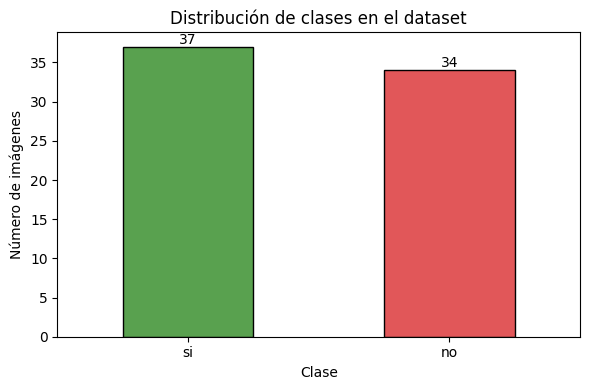


→ Clases con menos de 100 muestras pueden beneficiarse de data augmentation.


In [3]:
records = []
for clase in CLASES:
    carpeta = DATA_DIR / clase
    if not carpeta.exists():
        print(f"[AVISO] Carpeta no encontrada: {carpeta}")
        continue
    for img_path in sorted(carpeta.glob("*")):
        if img_path.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp"):
            records.append({
                "path"  : str(img_path),
                "label" : clase,
                "idx"   : LABEL2IDX[clase],
                "fname" : img_path.name,
            })

df = pd.DataFrame(records)
print(f"Total imágenes: {len(df)}")
print(df["label"].value_counts())

# ── Análisis de distribución de clases ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar", ax=ax, color=["#59a14f", "#e15759"], edgecolor="black")
ax.set_title("Distribución de clases en el dataset", fontsize=12)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()
print("\n→ Clases con menos de 100 muestras pueden beneficiarse de data augmentation.")

In [4]:
# ── Split principal ───────────────────────────────────────────────────────────
df_train, df_test = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED,
    stratify=df["label"], shuffle=True,
)
# Split de validación (del train)
df_tr, df_val = train_test_split(
    df_train, test_size=0.20, random_state=SEED,
    stratify=df_train["label"],
)
df_tr   = df_tr.reset_index(drop=True)
df_val  = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Train: {len(df_tr)}  |  Val: {len(df_val)}  |  Test: {len(df_test)}")

Train: 44  |  Val: 12  |  Test: 15


# Comparativa de modelos para detección de manos (mano / no mano)

---

## Comparativa de parámetros clave

| Característica | MobileNetV2 | MobileNetV3 Small | VGG16 |
|---|---|---|---|
| **Parámetros totales** | ~3,4 M | ~2,5 M | ~138 M |
| **Tamaño del modelo** | ~14 MB | ~10 MB | ~528 MB |
| **Top-1 Accuracy (ImageNet)** | 72,0 % | 67,4 % | 71,6 % |
| **MACs (operaciones)** | ~300 M | ~56 M | ~15,5 G |
| **Velocidad (inferencia CPU)** | Media | Alta | Muy baja |
| **Velocidad (inferencia GPU)** | Alta | Muy alta | Media |
| **Uso de memoria RAM** | Bajo | Muy bajo | Muy alto |
| **Adecuado para móvil / edge** | Sí | Sí (óptimo) | No |
| **Transfer learning** | Bueno | Bueno | Muy bueno |
| **Profundidad de la red** | 53 capas | 14 capas | 23 capas |

---

## Análisis por modelo

### MobileNetV2

- Arquitectura basada en bloques residuales invertidos con convoluciones depthwise separables.
- Buen equilibrio entre precisión y eficiencia; supera a VGG16 en velocidad con un tamaño ~38x menor.
- Compatible con TensorFlow Lite y ONNX para despliegue en dispositivos móviles.
- Adecuado si ya tienes experiencia con esta arquitectura y tu dataset es de tamaño medio-grande.

### MobileNetV3 Small

- Evolución de MobileNetV2: incorpora blocos SE (Squeeze-and-Excitation) y activaciones h-swish para mayor eficiencia.
- Diseñado mediante Neural Architecture Search (NAS), optimizado automáticamente para velocidad y precisión.
- Hasta 5x menos MACs que MobileNetV2 con una pérdida de precisión mínima en tareas de clasificación binaria.
- Ideal para inferencia en tiempo real, edge computing y dispositivos con batería.
- Para detección de manos (tarea relativamente simple), la menor precisión en ImageNet no supone una desventaja práctica.

### VGG16

- Arquitectura densa con capas convolucionales 3×3 apiladas; diseñada en 2014.
- Excelente base para transfer learning gracias a sus representaciones ricas y generalizables.
- Prohibitivamente costosa para inferencia en producción: 55x más parámetros que MobileNetV3 Small.
- Recomendable **solo** si el entorno dispone de GPU dedicada, la velocidad no es crítica, y se busca maximizar la precisión con un dataset pequeño (las features de VGG16 son muy robustas para fine-tuning).

---

## Características adicionales relevantes

### Consideraciones para fine-tuning

- **Dataset pequeño (< 5.000 imágenes):** VGG16 puede superar a los MobileNets si se congela la base y se entrena solo el clasificador, ya que sus features son muy descriptivas.
- **Dataset mediano / grande (> 10.000 imágenes):** MobileNetV3 converge bien y generaliza correctamente con fine-tuning completo.
- **Augmentación de datos:** Especialmente importante con MobileNetV3 al tener menos parámetros; técnicas como flip horizontal, rotación y cambios de brillo mejoran la robustez.

### Velocidad de entrenamiento

- MobileNetV3 Small entrena significativamente más rápido que VGG16 al tener ~55x menos parámetros.
- Con GPU modesta (RTX 3060), MobileNetV3 puede alcanzar 200-400 imágenes/segundo; VGG16 apenas supera las 80-100.

## 4 · Transforms, Augmentation y Dataset de PyTorch

### 4.1 · Pipeline SIN augmentation (baseline)

Transformaciones mínimas: solo resize y normalización ImageNet.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transforms baseline (sin augmentation) ───────────────────────────────────
transforms_base_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
transforms_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### 4.2 · Pipeline CON augmentation (albumentations)

Estrategia diseñada a partir del análisis de fallos del baseline:
- **Rotaciones y flips**: el modelo puede ver la mano desde distintos ángulos
- **Zoom / crop aleatorio**: simula variaciones en la distancia a la cámara
- **Brillo y contraste**: robustez ante diferentes condiciones de iluminación
- **Ruido gaussiano**: mejora la generalización ante imágenes ruidosas o comprimidas
- **Blur leve**: simula imágenes ligeramente desenfocadas

In [6]:
# ── Transforms CON augmentation (albumentations) ──────────────────────────────
#aug_pipeline = A.Compose([
 #   A.Resize(IMG_SIZE, IMG_SIZE),
  #  A.HorizontalFlip(p=0.5),
   # A.Rotate(limit=20, p=0.6),
#    A.RandomResizedCrop(height=IMG_SIZE, width=IMG_SIZE, scale=(0.8, 1.0), p=0.5),
 #   A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.6),
  #  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
   # A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    #A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
#    ToTensorV2(),
 #])


aug_pipeline = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.6),
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.8, 1.0),
        p=0.5
    ),

    A.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05,
        p=0.6
    ),

    A.GaussNoise(
        std_range=(0.04, 0.2),
        p=0.3
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    ToTensorV2(),
])

print("Pipeline de augmentation configurado con:")
for t in aug_pipeline.transforms:
    print(f"  - {t.__class__.__name__}")

Pipeline de augmentation configurado con:
  - Resize
  - HorizontalFlip
  - Rotate
  - RandomResizedCrop
  - ColorJitter
  - GaussNoise
  - GaussianBlur
  - Normalize
  - ToTensorV2


### 4.3 · Dataset y DataLoaders

In [7]:
class ImageDataset(Dataset):
    """Dataset compatible con transforms de torchvision y pipelines de albumentations."""
    def __init__(self, df, transform=None, use_albumentations=False):
        self.df               = df.reset_index(drop=True)
        self.transform        = transform
        self.use_albumentations = use_albumentations

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")
        label = row["idx"]
        if self.transform:
            if self.use_albumentations:
                img = np.array(img)
                img = self.transform(image=img)["image"]
            else:
                img = self.transform(img)
        return img, label, row["path"]


def make_loaders(df_tr, df_val, df_test, train_transform, use_alb=False):
    dl_train = DataLoader(
        ImageDataset(df_tr, train_transform, use_albumentations=use_alb),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
    )
    dl_val = DataLoader(
        ImageDataset(df_val, transforms_eval, use_albumentations=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    dl_test = DataLoader(
        ImageDataset(df_test, transforms_eval, use_albumentations=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    return dl_train, dl_val, dl_test


# DataLoaders BASELINE (sin augmentation)
dl_train_base, dl_val, dl_test = make_loaders(
    df_tr, df_val, df_test,
    train_transform=transforms_base_train, use_alb=False
)

# DataLoaders CON AUGMENTATION
dl_train_aug, _, _ = make_loaders(
    df_tr, df_val, df_test,
    train_transform=aug_pipeline, use_alb=True
)

print(f"Batches — train: {len(dl_train_base)}  val: {len(dl_val)}  test: {len(dl_test)}")

Batches — train: 3  val: 1  test: 1


### 4.4 · Visualización del pipeline de augmentation

Comparamos la misma imagen sin y con cada tipo de augmentation aplicada.

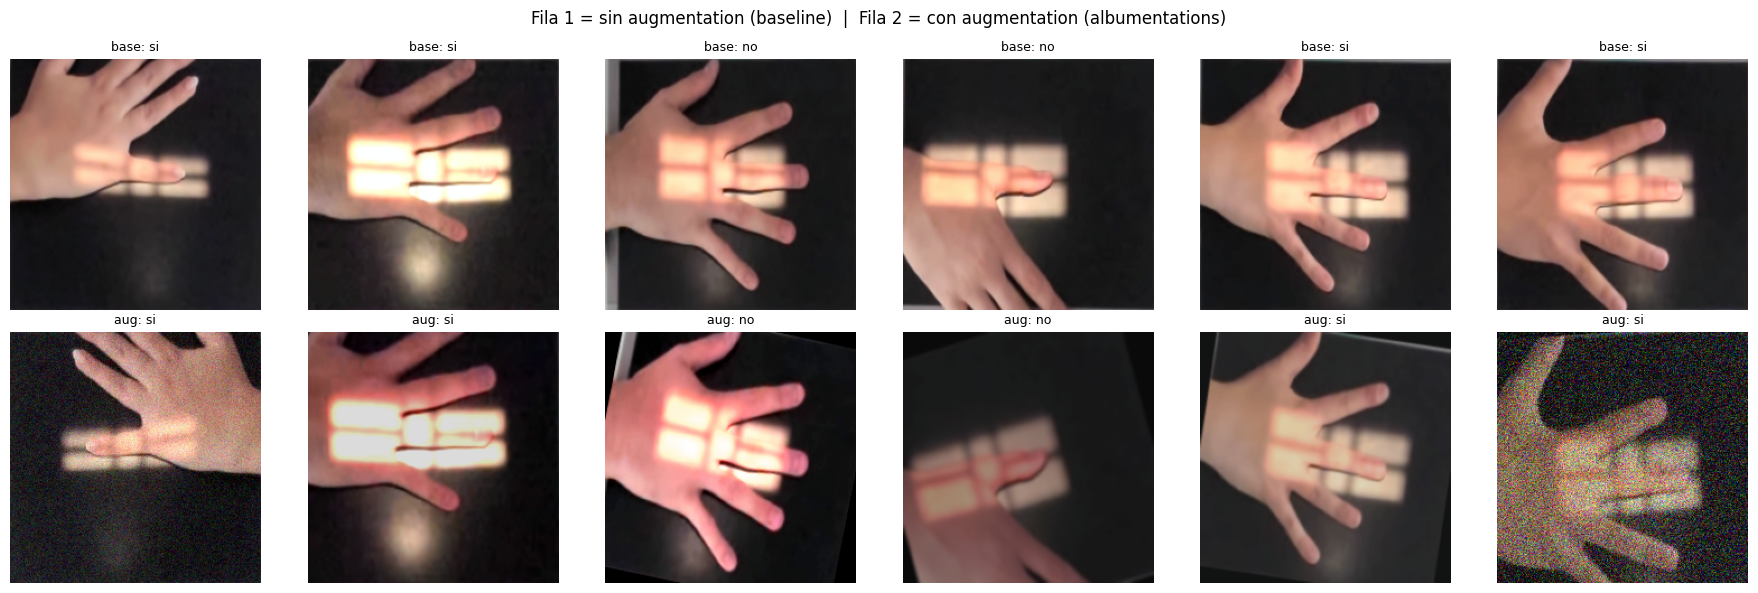

In [8]:
def denorm(img_tensor):
    """Desnormalizar tensor ImageNet para visualizar."""
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * np.array(IMAGENET_STD)) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)


# Visualizar efecto de la augmentation
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for col in range(6):
    row_tr = df_tr.iloc[col]
    img_pil = Image.open(row_tr["path"]).convert("RGB")
    lbl     = row_tr["idx"]

    # FILA 1: Sin augmentation
    img_base = transforms_base_train(img_pil)
    axes[0, col].imshow(denorm(img_base))
    axes[0, col].set_title(f"base: {IDX2LABEL[lbl]}", fontsize=9)
    axes[0, col].axis("off")

    # FILA 2: Con augmentation
    img_np  = np.array(img_pil)
    img_aug = aug_pipeline(image=img_np)["image"]
    axes[1, col].imshow(denorm(img_aug))
    axes[1, col].set_title(f"aug: {IDX2LABEL[lbl]}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Fila 1 = sin augmentation (baseline)  |  Fila 2 = con augmentation (albumentations)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Verificar batches de train, val y test
for loader_name, loader in [("train (baseline)", dl_train_base),
                             ("train (aug)",      dl_train_aug),
                             ("val",              dl_val),
                             ("test",             dl_test)]:
    images, labels, paths = next(iter(loader))
    print(f"{loader_name:20s} — imágenes: {images.shape}  labels: {labels.shape}")

print("\nPipeline de datos verificado ✓")

train (baseline)     — imágenes: torch.Size([16, 3, 224, 224])  labels: torch.Size([16])
train (aug)          — imágenes: torch.Size([16, 3, 224, 224])  labels: torch.Size([16])
val                  — imágenes: torch.Size([12, 3, 224, 224])  labels: torch.Size([12])
test                 — imágenes: torch.Size([15, 3, 224, 224])  labels: torch.Size([15])

Pipeline de datos verificado ✓


## 5 · Funciones auxiliares compartidas

In [10]:
# ── Loop de entrenamiento ─────────────────────────────────────────────────────
def entrenar(model, dl_train, dl_val, optimizer, criterion, epochs, scheduler=None,
             patience=7, min_delta=1e-4):

    best_wts     = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    es_counter   = 0
    stopped_at   = epochs

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        for phase, dl in [("train", dl_train), ("val", dl_val)]:
            model.train() if phase == "train" else model.eval()
            running_loss = running_correct = total = 0

            for imgs, labels, _ in dl:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    out   = model(imgs)
                    loss  = criterion(out, labels)
                    preds = out.argmax(dim=1)
                    if phase == "train":
                        loss.backward(); optimizer.step()
                running_loss    += loss.item() * imgs.size(0)
                running_correct += (preds == labels).sum().item()
                total           += imgs.size(0)

            ep_loss = running_loss / total
            ep_acc  = running_correct / total
            history[f"{phase}_loss"].append(ep_loss)
            history[f"{phase}_acc"].append(ep_acc)

            if phase == "val":
                if ep_acc > best_val_acc + min_delta:
                    best_val_acc = ep_acc
                    best_wts     = copy.deepcopy(model.state_dict())
                    es_counter   = 0
                else:
                    es_counter  += 1

        if scheduler: scheduler.step()
        print(f"  [{epoch:3d}/{epochs}]  "
              f"train {history['train_acc'][-1]:.3f}/{history['train_loss'][-1]:.4f}  "
              f"val {history['val_acc'][-1]:.3f}/{history['val_loss'][-1]:.4f}  "
              f"ES:{es_counter}/{patience}  ({time.time()-t0:.1f}s)")

        if es_counter >= patience:
            stopped_at = epoch
            print(f"  ⏹  Early stopping en época {epoch}  (sin mejora en {patience} épocas)")
            break

    print(f"  → Mejor val_acc: {best_val_acc:.3f}  |  Parado en época {stopped_at}/{epochs}")
    model.load_state_dict(best_wts)
    return model, history


# ── Evaluación en test ────────────────────────────────────────────────────────
def evaluar(model, dl_test):
    model.eval()
    all_preds, all_labels, all_paths = [], [], []
    with torch.no_grad():
        for imgs, labels, paths in dl_test:
            preds = model(imgs.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    y_true = [IDX2LABEL[l] for l in all_labels]
    y_pred = [IDX2LABEL[p] for p in all_preds]
    return y_true, y_pred, all_paths


def metricas_dict(nombre, y_true, y_pred):
    return {
        "Modelo"            : nombre,
        "Accuracy"          : accuracy_score(y_true, y_pred),
        "Balanced Acc."     : balanced_accuracy_score(y_true, y_pred),
        "Precision (si)"    : precision_score(y_true, y_pred, pos_label="si", zero_division=0),
        "Recall (si)"       : recall_score(y_true, y_pred, pos_label="si", zero_division=0),
        "F1 (si)"           : f1_score(y_true, y_pred, pos_label="si", zero_division=0),
    }

## 6 · Construcción de los modelos

### 6.1 · Factory function para MobileNetV2 y VGG16

In [11]:
def build_mobilenetv2(num_classes=2, dropout=0.4):
    """MobileNetV2 preentrenado con clasificador adaptado."""
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar todo el backbone inicialmente
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el clasificador final
    in_feat = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_feat, num_classes)
    )

    # Descongelar las últimas capas del backbone (features[14:] + classifier)
    for name, param in model.named_parameters():
        if "features.14" in name or "features.15" in name or \
           "features.16" in name or "features.17" in name or \
           "features.18" in name or "classifier" in name:
            param.requires_grad = True

    return model.to(device) 

# Mostrar resumen de parámetros
def resumen_parametros(model, nombre):
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"{nombre}: {n_train:,} entrenables / {n_total:,} total ({100*n_train/n_total:.1f}%)")

model_test = build_mobilenetv2()
resumen_parametros(model_test, "MobileNetV2")
del model_test

MobileNetV2: 1,683,906 entrenables / 2,226,434 total (75.6%)


---
## Modelo 1 · Baseline — MobileNetV2 SIN data augmentation

MobileNetV2 preentrenado con pesos ImageNet.  
Entrenado **sin ninguna augmentation** en el conjunto de train.  
Sirve como experimento de control: establece la línea base de rendimiento.

In [12]:
print("=" * 60)
print("MODELO 1 — MobileNetV2 BASELINE (sin augmentation)")
print("=" * 60)

model_base = build_mobilenetv2(num_classes=2, dropout=0.4)
resumen_parametros(model_base, "MobileNetV2 Baseline")

# ── Configurar optimizer con lr diferenciado ──────────────────────────────────
backbone_params_base = [p for n, p in model_base.named_parameters()
                        if p.requires_grad and "classifier" not in n]
head_params_base     = list(model_base.classifier.parameters())

criterion        = nn.CrossEntropyLoss()
optimizer_base   = optim.Adam([
    {"params": backbone_params_base, "lr": LR_BACKBONE},
    {"params": head_params_base,     "lr": LR_HEAD},
])
scheduler_base   = optim.lr_scheduler.CosineAnnealingLR(optimizer_base, T_max=EPOCHS_BASE)

# ── Entrenamiento ──────────────────────────────────────────────────────────────
model_base, history_base = entrenar(
    model_base, dl_train_base, dl_val,
    optimizer_base, criterion, EPOCHS_BASE, scheduler_base,
)

# ── Evaluación ────────────────────────────────────────────────────────────────
yt_base, yp_base, paths_base = evaluar(model_base, dl_test)
met_base = metricas_dict("Baseline (sin aug)", yt_base, yp_base)

print("\nMétricas Baseline:")
for k, v in met_base.items():
    if k != "Modelo":
        print(f"  {k:20s}: {v:.3f}")

# ── Guardar checkpoint baseline ───────────────────────────────────────────────
torch.save(model_base.state_dict(), "mobilenet_baseline.pt")
print("\nCheckpoint guardado: mobilenet_baseline.pt")

MODELO 1 — MobileNetV2 BASELINE (sin augmentation)
MobileNetV2 Baseline: 1,683,906 entrenables / 2,226,434 total (75.6%)
  [  1/15]  train 0.477/0.7706  val 0.417/0.6948  ES:0/7  (1.7s)
  [  2/15]  train 0.591/0.6824  val 0.500/0.7035  ES:0/7  (1.4s)
  [  3/15]  train 0.705/0.6275  val 0.417/0.7110  ES:1/7  (1.5s)
  [  4/15]  train 0.750/0.5992  val 0.417/0.6986  ES:2/7  (1.4s)
  [  5/15]  train 0.841/0.5018  val 0.583/0.6982  ES:0/7  (1.4s)
  [  6/15]  train 0.932/0.3810  val 0.583/0.6997  ES:1/7  (1.4s)
  [  7/15]  train 0.818/0.4308  val 0.417/0.7059  ES:2/7  (1.5s)
  [  8/15]  train 0.932/0.3649  val 0.500/0.7028  ES:3/7  (1.4s)
  [  9/15]  train 0.886/0.3607  val 0.583/0.7028  ES:4/7  (1.5s)
  [ 10/15]  train 0.977/0.3339  val 0.667/0.7035  ES:0/7  (1.5s)
  [ 11/15]  train 0.909/0.3664  val 0.667/0.7047  ES:1/7  (1.5s)
  [ 12/15]  train 0.955/0.3168  val 0.667/0.7121  ES:2/7  (1.4s)
  [ 13/15]  train 0.864/0.3779  val 0.667/0.7206  ES:3/7  (1.4s)
  [ 14/15]  train 0.977/0.2667  va

### Análisis de errores del baseline

Identificamos las imágenes que el baseline clasifica mal para diseñar la estrategia de augmentation.

MobileNetV2 Baseline: 7 errores de 15 (46.7% error)


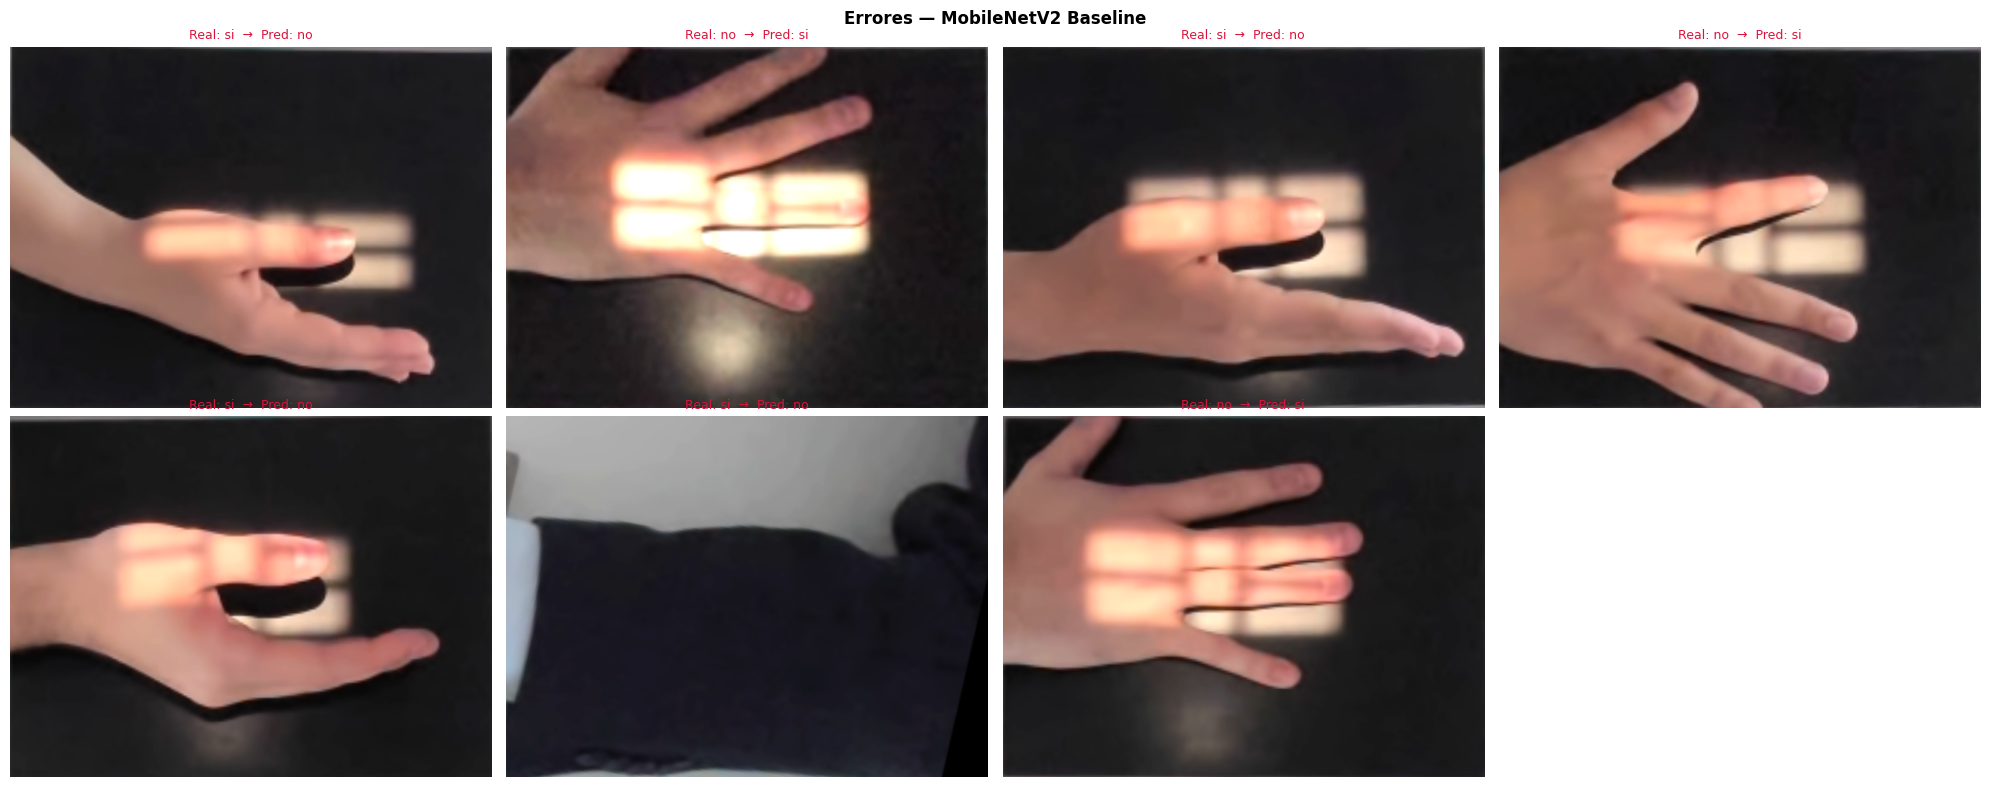

In [13]:
def mostrar_errores(yt, yp, paths, nombre, max_show=8):
    errores = [(p, t, pr) for p, t, pr in zip(paths, yt, yp) if t != pr]
    print(f"{nombre}: {len(errores)} errores de {len(yt)} ({100*len(errores)/len(yt):.1f}% error)")
    n = min(max_show, len(errores))
    if n == 0:
        print("  ¡Sin errores!")
        return
    cols_g = min(4, n)
    rows_g = (n + cols_g - 1) // cols_g
    fig, axes = plt.subplots(rows_g, cols_g, figsize=(5 * cols_g, 4 * rows_g))
    axes = np.array(axes).flatten()
    for i, (path, yt_i, yp_i) in enumerate(errores[:n]):
        img = Image.open(path).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"Real: {yt_i}  →  Pred: {yp_i}",
                          color="crimson", fontsize=9)
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"Errores — {nombre}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

mostrar_errores(yt_base, yp_base, paths_base, "MobileNetV2 Baseline")

---
## Modelo 2 · MobileNetV2 CON data augmentation

Misma arquitectura y configuración que el baseline, pero entrenado con el pipeline de albumentations activado.  
El conjunto de validación y test **no recibe augmentation** para una comparación justa.

In [14]:
print("=" * 60)
print("MODELO 2 — MobileNetV2 CON DATA AUGMENTATION")
print("=" * 60)

model_aug = build_mobilenetv2(num_classes=2, dropout=0.4)
resumen_parametros(model_aug, "MobileNetV2 + Augmentation")

# ── Mismo optimizer que baseline para comparación justa ───────────────────────
backbone_params_aug = [p for n, p in model_aug.named_parameters()
                       if p.requires_grad and "classifier" not in n]
head_params_aug     = list(model_aug.classifier.parameters())

optimizer_aug = optim.Adam([
    {"params": backbone_params_aug, "lr": LR_BACKBONE},
    {"params": head_params_aug,     "lr": LR_HEAD},
])
scheduler_aug = optim.lr_scheduler.CosineAnnealingLR(optimizer_aug, T_max=EPOCHS_AUG)

# ── Entrenamiento CON augmentation ────────────────────────────────────────────
model_aug, history_aug = entrenar(
    model_aug, dl_train_aug, dl_val,       # <-- dl_train_aug con albumentations
    optimizer_aug, criterion, EPOCHS_AUG, scheduler_aug,
)

# ── Evaluación ────────────────────────────────────────────────────────────────
yt_aug, yp_aug, paths_aug = evaluar(model_aug, dl_test)
met_aug = metricas_dict("Con Augmentation", yt_aug, yp_aug)

print("\nMétricas Con Augmentation:")
for k, v in met_aug.items():
    if k != "Modelo":
        print(f"  {k:20s}: {v:.3f}")

# ── Guardar checkpoint augmentation ──────────────────────────────────────────
torch.save(model_aug.state_dict(), "mobilenet_augmentation.pt")
print("\nCheckpoint guardado: mobilenet_augmentation.pt")

MODELO 2 — MobileNetV2 CON DATA AUGMENTATION
MobileNetV2 + Augmentation: 1,683,906 entrenables / 2,226,434 total (75.6%)
  [  1/15]  train 0.409/0.7815  val 0.417/0.7088  ES:0/7  (1.4s)
  [  2/15]  train 0.386/0.8004  val 0.417/0.7317  ES:1/7  (1.4s)
  [  3/15]  train 0.614/0.6373  val 0.417/0.7441  ES:2/7  (1.4s)
  [  4/15]  train 0.455/0.7365  val 0.333/0.7541  ES:3/7  (1.5s)
  [  5/15]  train 0.568/0.6870  val 0.500/0.7512  ES:0/7  (1.4s)
  [  6/15]  train 0.591/0.7055  val 0.417/0.7783  ES:1/7  (1.4s)
  [  7/15]  train 0.705/0.6529  val 0.500/0.7856  ES:2/7  (1.4s)
  [  8/15]  train 0.591/0.6381  val 0.417/0.7633  ES:3/7  (1.4s)
  [  9/15]  train 0.659/0.6203  val 0.500/0.7351  ES:4/7  (1.4s)
  [ 10/15]  train 0.705/0.6022  val 0.417/0.7365  ES:5/7  (1.4s)
  [ 11/15]  train 0.659/0.6756  val 0.417/0.7385  ES:6/7  (1.4s)
  [ 12/15]  train 0.614/0.6631  val 0.417/0.7249  ES:7/7  (1.4s)
  ⏹  Early stopping en época 12  (sin mejora en 7 épocas)
  → Mejor val_acc: 0.500  |  Parado en ép

---
## Comparativa final

### Tabla de métricas

In [15]:
COLS = ["Accuracy", "Balanced Acc.", "Precision (si)", "Recall (si)", "F1 (si)"]

PALETTE = {
    "Baseline (sin aug)" : "#4e79a7",
    "Con Augmentation"   : "#f28e2b",
}

df_comp = pd.DataFrame([met_base, met_aug]).set_index("Modelo")
df_pct  = (df_comp[COLS] * 100).round(2)

print(df_pct.to_string())

styled = df_pct.style\
    .highlight_max(axis=0, color="#b7e4c7")\
    .highlight_min(axis=0, color="#ffb3b3")\
    .format("{:.2f} %")
styled

                    Accuracy  Balanced Acc.  Precision (si)  Recall (si)  F1 (si)
Modelo                                                                           
Baseline (sin aug)     53.33          53.57           57.14         50.0    53.33
Con Augmentation       60.00          59.82           62.50         62.5    62.50


,Accuracy,Balanced Acc.,Precision (si),Recall (si),F1 (si)
Modelo,,,,,
Baseline (sin aug),53.33 %,53.57 %,57.14 %,50.00 %,53.33 %
Con Augmentation,60.00 %,59.82 %,62.50 %,62.50 %,62.50 %


### Gráfica de barras — todas las métricas

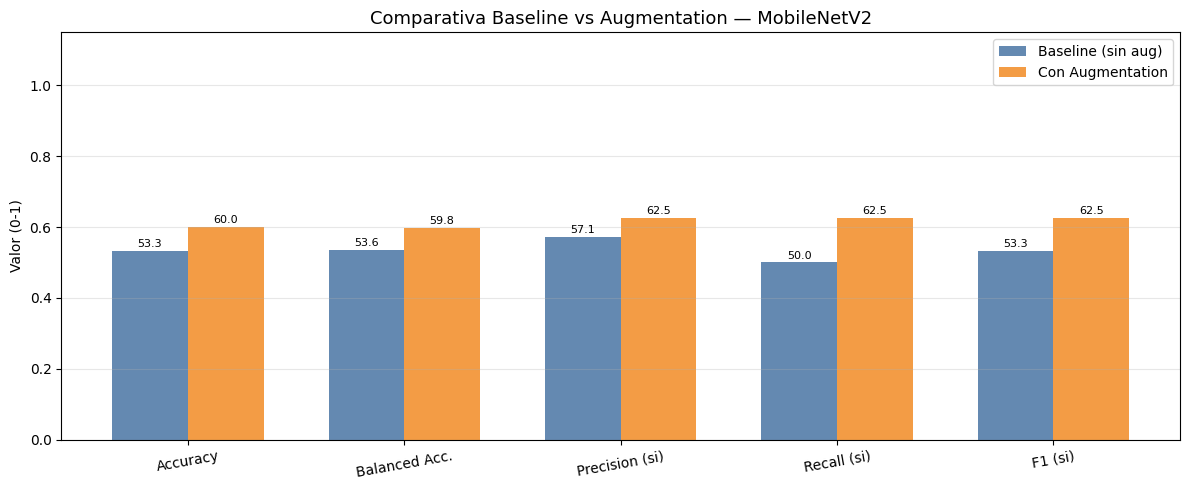

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(COLS))
width = 0.35

for i, (nombre, row) in enumerate(df_comp[COLS].iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=nombre, color=PALETTE[nombre], alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h*100:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(COLS, rotation=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor (0-1)")
ax.set_title("Comparativa Baseline vs Augmentation — MobileNetV2", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Curvas de entrenamiento — Loss y Accuracy

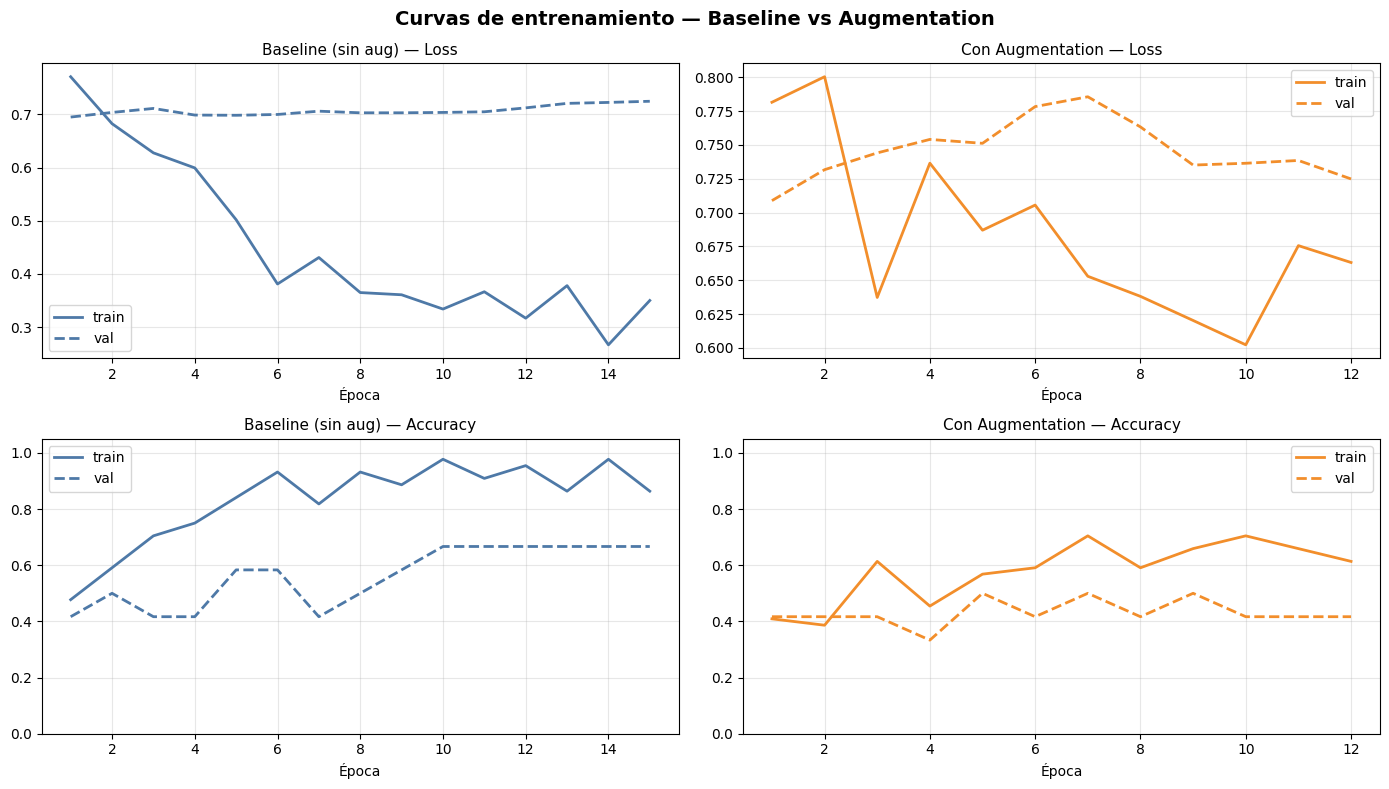

In [17]:
modelos_con_historia = [
    ("Baseline (sin aug)", history_base, PALETTE["Baseline (sin aug)"]),
    ("Con Augmentation",   history_aug,  PALETTE["Con Augmentation"]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (nombre, hist, color) in enumerate(modelos_con_historia):
    epochs = range(1, len(hist["train_loss"]) + 1)

    # Loss
    axes[0, col].plot(epochs, hist["train_loss"], color=color, lw=2,        label="train")
    axes[0, col].plot(epochs, hist["val_loss"],   color=color, lw=2, ls="--", label="val")
    axes[0, col].set_title(f"{nombre} — Loss", fontsize=11)
    axes[0, col].set_xlabel("Época"); axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Accuracy
    axes[1, col].plot(epochs, hist["train_acc"], color=color, lw=2,        label="train")
    axes[1, col].plot(epochs, hist["val_acc"],   color=color, lw=2, ls="--", label="val")
    axes[1, col].set_title(f"{nombre} — Accuracy", fontsize=11)
    axes[1, col].set_xlabel("Época"); axes[1, col].legend()
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Curvas de entrenamiento — Baseline vs Augmentation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Matrices de confusión (heatmaps)

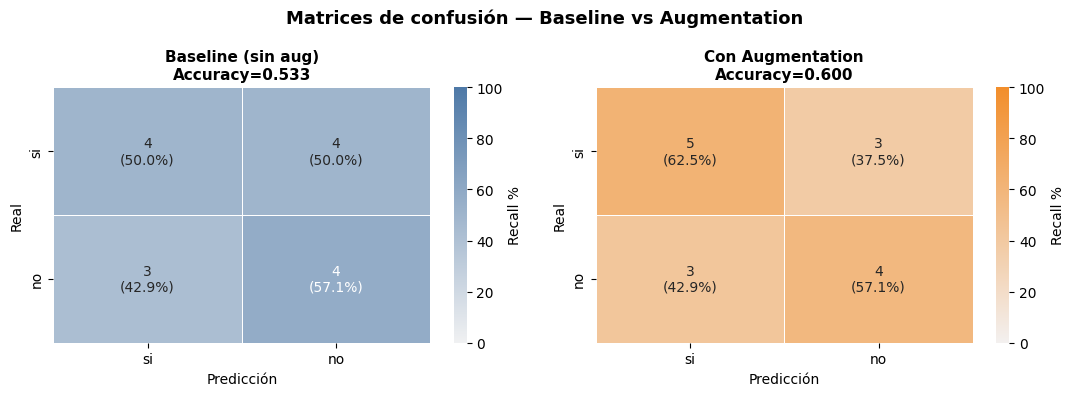

In [18]:
modelos_eval = [
    ("Baseline (sin aug)", yt_base, yp_base, PALETTE["Baseline (sin aug)"]),
    ("Con Augmentation",   yt_aug,  yp_aug,  PALETTE["Con Augmentation"]),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (nombre, yt, yp, color) in zip(axes, modelos_eval):
    cm = confusion_matrix(yt, yp, labels=["si", "no"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_c, row_p)]
                       for row_c, row_p in zip(cm, cm_pct)])

    sns.heatmap(
        cm_pct, annot=annot, fmt="", ax=ax,
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=["si", "no"],
        yticklabels=["si", "no"],
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Recall %"},
        vmin=0, vmax=100,
    )
    acc = accuracy_score(yt, yp)
    ax.set_title(f"{nombre}\nAccuracy={acc:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión — Baseline vs Augmentation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Radar chart — perfil de cada modelo

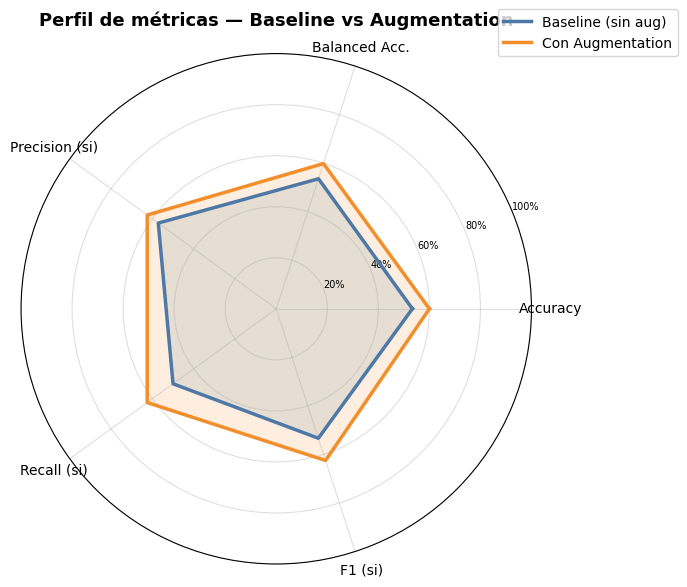

In [19]:
labels_radar = COLS
N = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for nombre, row in df_comp[COLS].iterrows():
    values = row.values.tolist() + [row.values[0]]
    ax.plot(angles, values, lw=2.5, label=nombre, color=PALETTE[nombre])
    ax.fill(angles, values, alpha=0.15, color=PALETTE[nombre])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=7)
ax.set_title("Perfil de métricas — Baseline vs Augmentation",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Análisis de errores — ambos modelos

Baseline (sin aug): 7 errores de 15 (46.7% error)


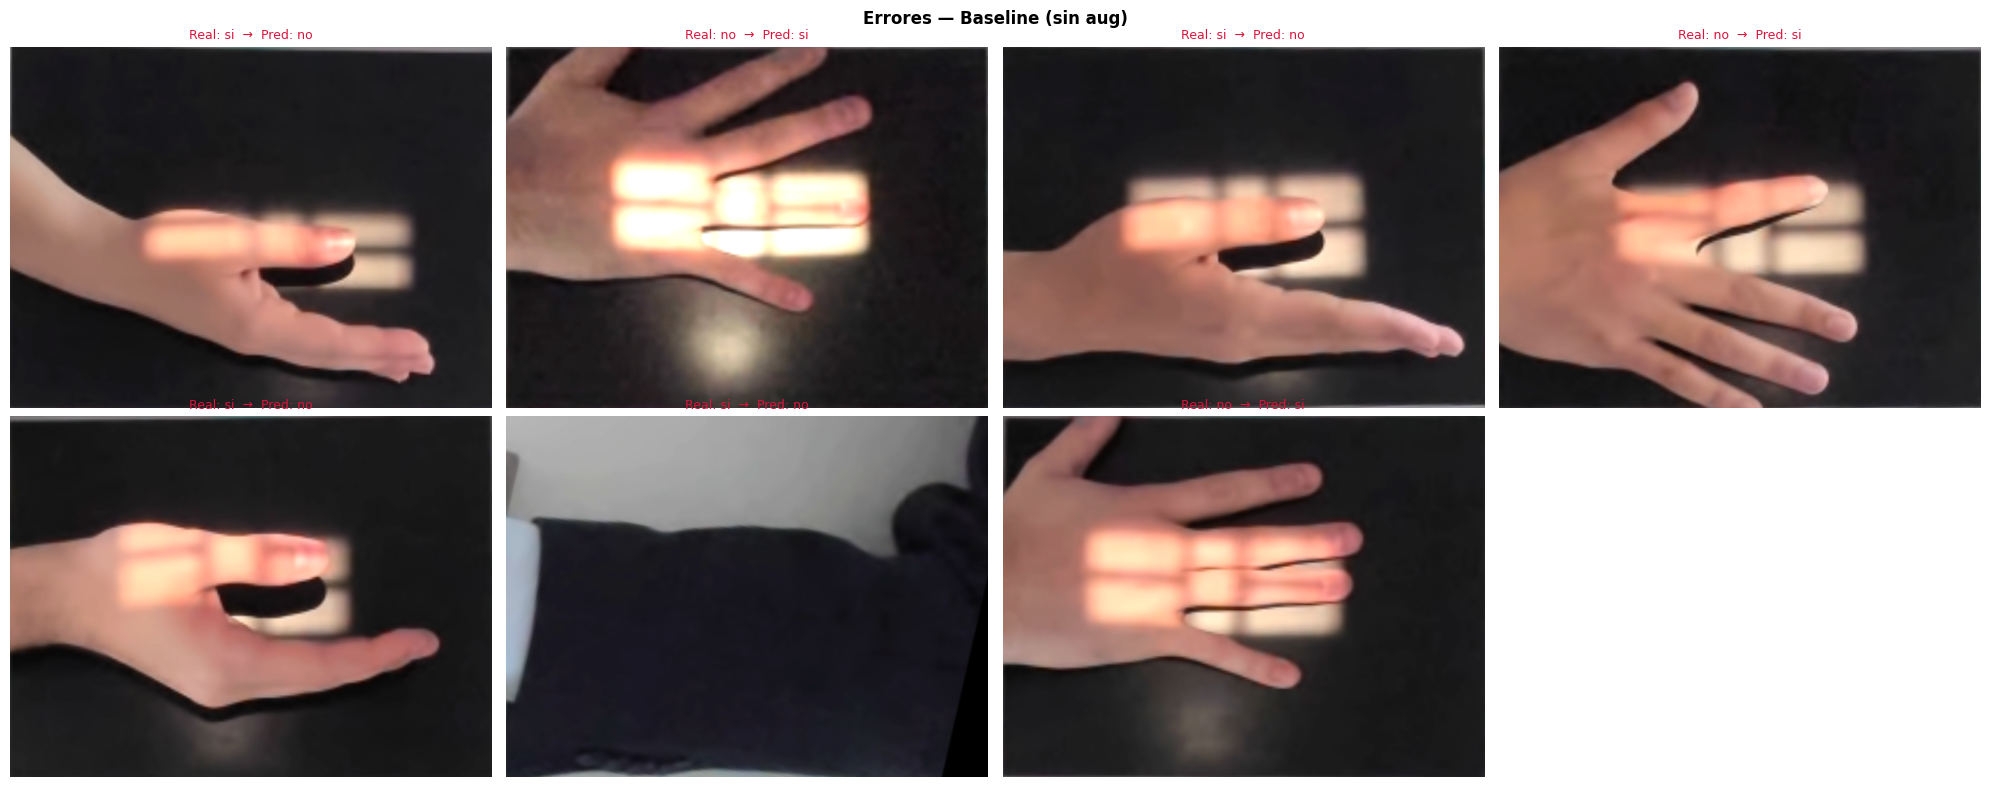

Con Augmentation: 6 errores de 15 (40.0% error)


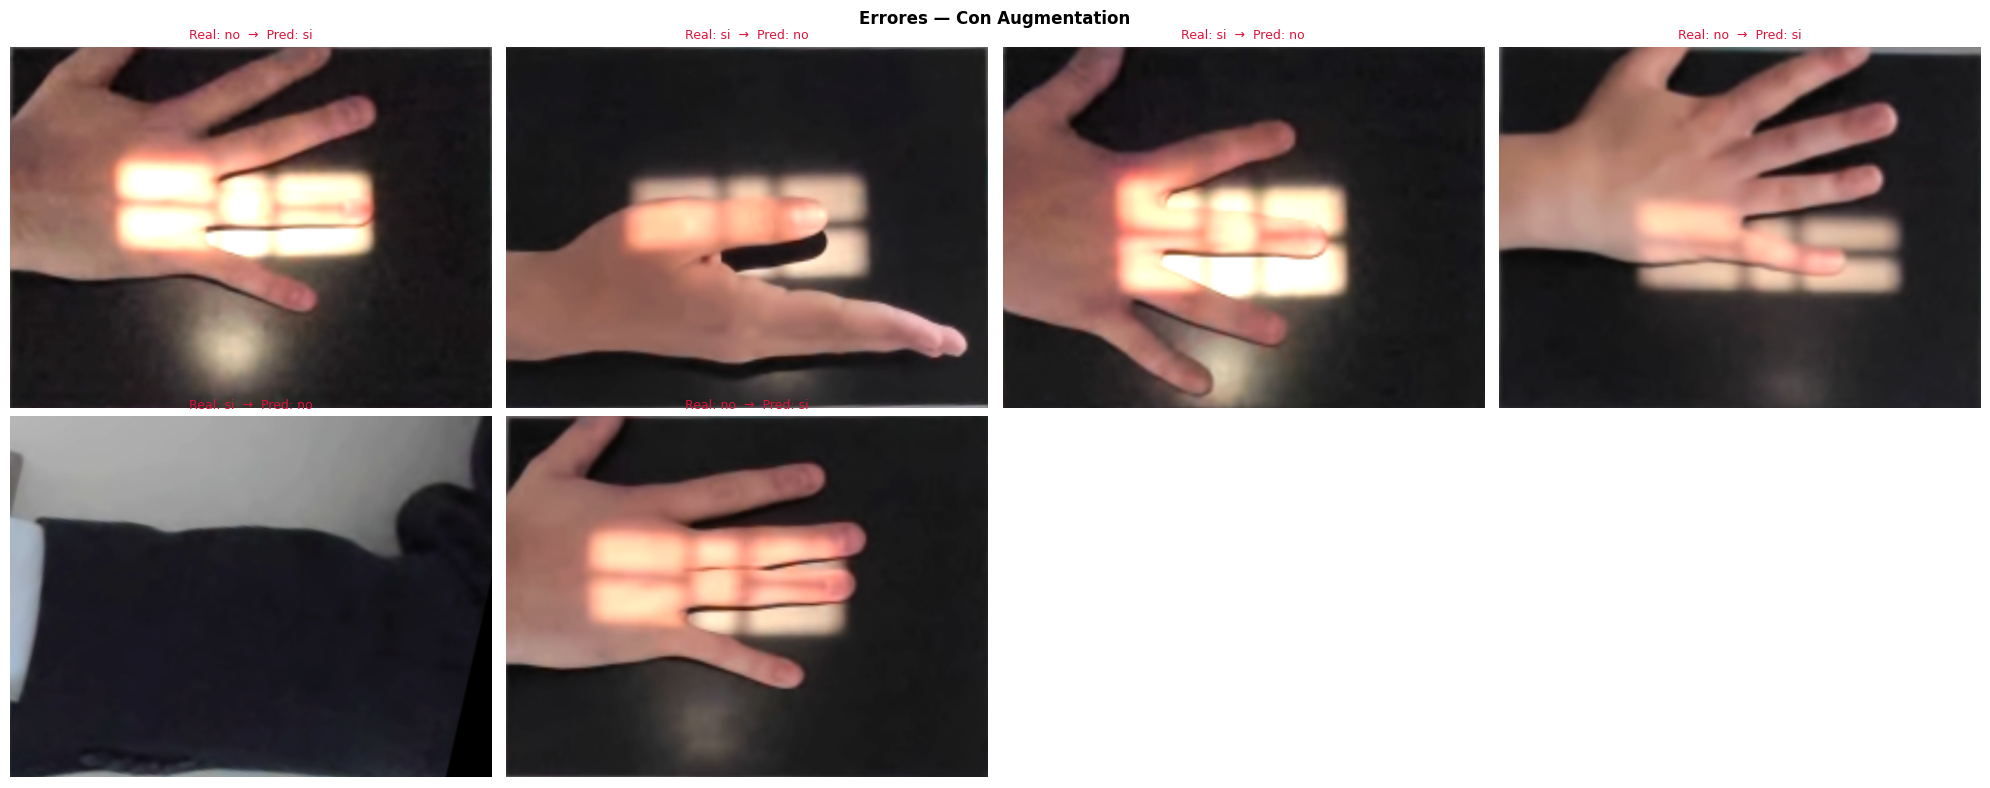

In [20]:
for nombre, yt, yp, paths in [
    ("Baseline (sin aug)", yt_base, yp_base, paths_base),
    ("Con Augmentation",   yt_aug,  yp_aug,  paths_aug),
]:
    mostrar_errores(yt, yp, paths, nombre)

---
## Informe técnico

### Análisis del experimento de Data Augmentation

#### 1. Contexto
Se ha entrenado MobileNetV2 preentrenado en ImageNet bajo dos condiciones:
- **Baseline:** sin augmentation, solo resize + normalización
- **Con Augmentation:** pipeline completo de albumentations (flips, rotaciones, zoom, brillo, ruido, blur)

#### 2. Augmentations aplicadas y justificación

| Augmentation | Parámetros | Justificación |
|---|---|---|
| HorizontalFlip | p=0.5 | Simetría de la mano |
| Rotate | ±20°, p=0.6 | Variaciones de orientación en imágenes reales |
| RandomResizedCrop | scale=[0.8, 1.0], p=0.5 | Variación en distancia a la cámara |
| ColorJitter | brillo/contraste ±0.3, p=0.6 | Distintas condiciones de iluminación |
| GaussNoise | var=[10,50], p=0.3 | Robustez ante cámaras de baja calidad |
| GaussianBlur | kernel=[3,5], p=0.2 | Imágenes ligeramente desenfocadas |

#### 3. Resultados

- **¿Mejoró la augmentation?** →  
- **Clases más beneficiadas:** →  
- **Augmentations más efectivas:** →  
- **Augmentations sin efecto notable:** →  

#### 4. Conclusiones TODO

*Rellenar tras el análisis de resultados.*

---

### Borrador publicación web

**"Un agente que mejora solo el entrenamiento de nuestra IA"**

¿Qué ocurre cuando le das a una red neuronal más formas de ver el mundo? En este proyecto hemos explorado cómo el data augmentation — la técnica de generar variaciones artificiales de las imágenes de entrenamiento — puede mejorar significativamente la capacidad de generalización de modelos de visión artificial.

Usando MobileNetV2, una arquitectura diseñada para ser eficiente sin sacrificar precisión, hemos comparado el rendimiento del modelo entrenado con transformaciones mínimas frente al entrenado con un pipeline completo de augmentation: rotaciones, cambios de brillo, ruido y más.

Los resultados revelan no solo cuánto mejora la métrica global, sino también *qué clases* se benefician más — y por qué. La clave está en diseñar augmentations coherentes con la variabilidad real del problema, no en aplicarlas todas ciegamente.